## Transformers for cognitive tasks: context-dependendent sequence generation.
-  This is a demo as part of a study comparing the differences in performance and representation between transformer-based architectures, and recurrent neural network (RNN) architectures. 
-  Motivation: How do different architectures handle computations that require knowledge of sequences across long time dependencies? 
-  Task: Sequences are generated using a small synthetic vocabularly to mimic sentences. Sentences begin with one of two target words: token= 0 or token=5000. the target sentence should sort the words of that sentence in ascending order. If token=5000, the sentence should be sorted in descending order. 
-  Model: This demo utilizees a PyTorch Lightning wrapper around a transformer that closely follows the 2017 "Attention is all you need" architecture 
-  Analysis: For now, the anlaysis focuses on looking at trained dot-production attention values to see how start tokens get associated with other tokens in their sequence



In [5]:
# load modules
import sys, math, copy
sys.path.append('/Users/dhocker/projects')
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from cogtrans.src.model import Transformer
from cogtrans.src.model import LitAutoEncoder
import lightning as L
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

%load_ext autoreload
%autoreload 2


## Task
- here we structure the vocabulalry for our experiment, which is just a set of integers ranging from 0 to `nvocab`
- the target sequences will be either forward-sorted or reverse-sorted version of each sentence

In [7]:
# build your vocab and syntax
nvocab = 5000
vocab1 = np.linspace(1,nvocab,nvocab).astype(int)
vocab2 = vocab1
print(len(np.unique(vocab1)))

# syntax is that toekn 0 and `nvocab` start sentences.
# the target output for that sentence is context dependent
# when 0 starts sentence, words should order increasing size
# when `nvocab` starts a sentence, words should order decreasing size

# [0,1,4,2,6,8,7]       ---> [0, 1,2,4,6,7,8]
# [nvocab,1,4,2,6,8,7]  ---> [nvocab, 8,7,6,4,2,1]

# data parameters
nt = 100  # number tokens per sentence
ns = 64 # batch size
nstart = 10  # number of sentences

def build_data_vocab1(vocab,nt,ns,nstart):
    """ creates a vocab  using 'words' from vocab. size ns samples x nt time points. nstart
    number of sentences per sample"""
    np.random.seed(101)
    
    data = np.random.choice(vocab[1:-1],(ns,nt),replace=True) #omit start and end words, as they are sentence start
    # add some sentence starts. don't let it be first 2 or last two words
    starts = np.array([np.random.choice(np.linspace(2,nt-3,nt-4).astype(int),(nstart-1),replace=False) for k in range(ns)])
    # make first word be a start
    starts = np.concatenate((np.zeros((ns,1)).astype(int),starts),axis=1)

    #decide if forward or reverse translaion sentence
    start_type = np.random.choice([vocab[0],vocab[-1]],(ns,nstart),replace=True)

    for j in range(ns):
        data[j,starts[j,:]] = start_type[j,:]
        
    return data

def translate_vocab1(data,vocab):
    """ translates vocab1 in a context dependent way"""
    
    ns,nt = data.shape
    new_data = np.zeros((ns,nt)).astype(int)

    for j in range(ns):  

        #find starts
        idx_start = np.argwhere((data[j,:]==vocab[0]) | (data[j,:] == vocab[-1]))[:,0]
        dat_tmp_j = copy.deepcopy(data[j,:])
        for k in range(nstart-1):
            # re-order sentence in ascending order
            if dat_tmp_j[idx_start[k]]==vocab1[0]:
                dat_tmp_j[idx_start[k]:idx_start[k+1]] = np.sort(dat_tmp_j[idx_start[k]:idx_start[k+1]])
            else: #if sentence starts with vocab1[-1] reorder "sentence" indescending order
                test = np.sort(dat_tmp_j[idx_start[k]:idx_start[k+1]])[::-1]
                dat_tmp_j[idx_start[k]:idx_start[k+1]] = test
        new_data[j,:] = dat_tmp_j

    return new_data

# build the data
data = build_data_vocab1(vocab1,nt,ns,nstart)
trg_data = translate_vocab1(data,vocab1)
print(data.shape)
print(trg_data.shape)

5000
(64, 100)
(64, 100)


In [8]:
# just check vocab values
print('single  input sequence example')
print(data[0,:])
print('and single target sequence')
print(trg_data[0,:])

single  input sequence example
[   1 1549 1363  601 4173 4081  975 2625 3831 4830    1  910 4575   51
 4721 1532 2186 4469 1951 2933 2109 1582 3914 1275 2325 3980    1  345
 1529 3531 5000 3173 3358 4929  908  438 3689 3403 3577 1353 2961 4610
 3702 4460 2323 4858 2253 1489 3777 2548 4517 3084 4597 1982 1302 2973
 3850 1880 2428 1820 1525 3929 3760 4145 3000 2791 2264 1023 1711 1428
 1596 5000  909    1 5000 2469 4638 4101 4949 1329    1 2759  634  949
 4058 3440 2121  359 4038 1270    1 3281 2276    1 1487 4144 1584 2023
 4895 3223]
and single target sequence
[   1  601  975 1363 1549 2625 3831 4081 4173 4830    1   51  910 1275
 1532 1582 1951 2109 2186 2325 2933 3914 3980 4469 4575 4721    1  345
 1529 3531 5000 4929 4858 4610 4597 4517 4460 4145 3929 3850 3777 3760
 3702 3689 3577 3403 3358 3173 3084 3000 2973 2961 2791 2548 2428 2323
 2264 2253 1982 1880 1820 1711 1596 1525 1489 1428 1353 1302 1023  908
  438 5000  909    1 5000 4949 4638 4101 2469 1329    1  359  634  949
 1270 2

## Model
- the transformer architecture here is the same as classic "Attention is all you need" paper. Chosen as a minimal working example for transformers on sequences without going overboard on model size
- embedding words in a 512-D space
- 8 attention heads
- 6 feed forward layers after the attenion

In [10]:
# structure the data and transformer

src_vocab_size = nvocab+1  # Vocab size
tgt_vocab_size = nvocab+1  # Vocab size. keep in same vocab for now
d_model = 512  #word embedding dimension. 
num_heads = 8  #num. attention heads: parses which parts of the embedding space will be attended to?
num_layers = 6 # number of feed forward layers after attention
d_ff = 2048  # TODO
max_seq_length = 100  # maximum length of sentences
dropout = 0.1  # dropout proportion in parameter training

# my training data
src_data = torch.tensor(data)
tgt_data = torch.tensor(trg_data)

# model
transformer = Transformer(src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout)


## Optimizaition
- Just doing the typical things for sequence modeling: Cross entropy loss with an Adam optimizer
- Using PyTorch Lighting for easy training loops, and clearML for logging

In [14]:
# optimization. Cross entropy loss and Adam optimizer
uselightning = True
numepoch = 10
if not uselightning:
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    optimizer = optim.Adam(transformer.parameters(), lr=0.0001, betas=(0.9, 0.98), eps=1e-9)
    
    transformer.train()
    
    for epoch in range(numepoch):
        optimizer.zero_grad()
        output = transformer(src_data, tgt_data[:, :-1])
        #todo
        loss = criterion(output.contiguous().view(-1, tgt_vocab_size), tgt_data[:, 1:].contiguous().view(-1))
        loss.backward()
        optimizer.step()
        print(f"Epoch: {epoch+1}, Loss: {loss.item()}")
else:
    # run an equivalent lightning verion
    dataset = TensorDataset(src_data, tgt_data[:, :-1])
    dataloader = DataLoader(dataset, batch_size=ns, shuffle=True)
    transformer_lit = LitAutoEncoder(transformer, tgt_vocab_size)
    trainer = L.Trainer(max_epochs=numepoch, accelerator="cpu")
    trainer.fit(model=transformer_lit, train_dataloaders=dataloader)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name        | Type        | Params | Mode  | FLOPs
------------------------------------------------------------
0 | transformer | Transformer | 51.8 M | train | 0    
------------------------------------------------------------
51.8 M    Trainable params
0         Non-trainable params
51.8 M    Total params
207.300   Total estimated model params size (MB)
200       Modules in train mode
0         Modules in eval mode
0         Total Flops


Training: |                                                                                                 | …

`Trainer.fit` stopped: `max_epochs=10` reached.


In [15]:
# save
dosave = True
doload = False

savepath = '/Users/dhocker/projects/llm/results/'
if dosave:
    torch.save(transformer.state_dict(), savepath+'transformer_20260113.model')
if doload:
    transformer.load_state_dict(torch.load(savepath+'transformer_20260113.model', weights_only=True))
    

## Analysis
Let's see what the dot product attenion values look like for start tokens across the different heads

In [17]:
#quick check of performance. how well did you capture the sequence?

output = transformer(src_data, tgt_data[:, :-1])
print(src_data[0,:])
print(tgt_data[0,:])
preds = np.argmax(output[0,:,:].detach().numpy(),axis=-1)
print(preds)


tensor([   1, 1549, 1363,  601, 4173, 4081,  975, 2625, 3831, 4830,    1,  910,
        4575,   51, 4721, 1532, 2186, 4469, 1951, 2933, 2109, 1582, 3914, 1275,
        2325, 3980,    1,  345, 1529, 3531, 5000, 3173, 3358, 4929,  908,  438,
        3689, 3403, 3577, 1353, 2961, 4610, 3702, 4460, 2323, 4858, 2253, 1489,
        3777, 2548, 4517, 3084, 4597, 1982, 1302, 2973, 3850, 1880, 2428, 1820,
        1525, 3929, 3760, 4145, 3000, 2791, 2264, 1023, 1711, 1428, 1596, 5000,
         909,    1, 5000, 2469, 4638, 4101, 4949, 1329,    1, 2759,  634,  949,
        4058, 3440, 2121,  359, 4038, 1270,    1, 3281, 2276,    1, 1487, 4144,
        1584, 2023, 4895, 3223])
tensor([   1,  601,  975, 1363, 1549, 2625, 3831, 4081, 4173, 4830,    1,   51,
         910, 1275, 1532, 1582, 1951, 2109, 2186, 2325, 2933, 3914, 3980, 4469,
        4575, 4721,    1,  345, 1529, 3531, 5000, 4929, 4858, 4610, 4597, 4517,
        4460, 4145, 3929, 3850, 3777, 3760, 3702, 3689, 3577, 3403, 3358, 3173,
       

In [18]:
# grab the attention activation for the forward pieces for the transformer

# get sample data
src_mask, tgt_mask = transformer.generate_mask(src_data, tgt_data)
src_embedded = transformer.dropout(transformer.positional_encoding(transformer.encoder_embedding(src_data)))
tgt_embedded = transformer.dropout(transformer.positional_encoding(transformer.decoder_embedding(tgt_data)))

attn = []
for enc_layer in transformer.encoder_layers:
    attn_k = enc_layer.self_attn(src_embedded, src_embedded, src_embedded, src_mask)
    attn.append(attn_k)



In [19]:
#manually look at the attention probs

layerhead_idx = 0  # which attention head are you looking at?

a1 = transformer.encoder_layers[layerhead_idx].self_attn

Q = a1.split_heads(a1.W_q(src_embedded))
K = a1.split_heads(a1.W_k(src_embedded))
V = a1.split_heads(a1.W_v(src_embedded))
print(Q.shape)

# Perform scaled dot-product attention
attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(a1.d_k)
if src_mask is not None:
    attn_scores = attn_scores.masked_fill(src_mask == 0, -1e9)
attn_probs = torch.softmax(attn_scores, dim=-1)
attn_probs.shape


torch.Size([64, 8, 100, 64])


torch.Size([64, 8, 100, 100])

(100,)


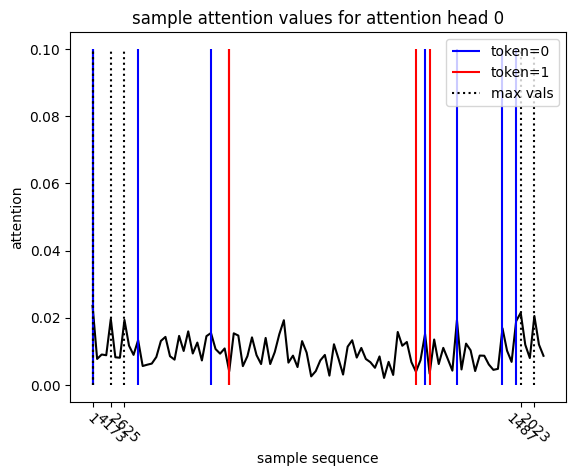

In [21]:
# look to see how each attention layer "notices" sentence starts
head_idx = 0
batch_idx = 0
#print(attn_probs[0,head_idx,0,:])
t_idx = 1

X = attn_probs[batch_idx,head_idx,t_idx,:].detach().numpy()

plt.plot(X,color='k')
x = np.argwhere(src_data[0,:].detach().numpy()==1)[:,0]
y = np.argwhere(src_data[0,:].detach().numpy()==vocab1[-1])[:,0]
plt.vlines(x[0],0,0.1,color='blue',label='token=0')
plt.vlines(y[0],0,0.1,color='red', label='token=1')

[plt.vlines(k,0,0.1,color='blue') for k in x]
[plt.vlines(k,0,0.1,color='red') for k in y]

# find top 5 largest values
I = np.argsort(X)[::-1]
labels = [str(src_data[0,I[k]].detach().numpy()) for k in range(5)]
print(I.shape)
plt.vlines(I[0],0,0.1,color='black',linestyle = 'dotted',label='max vals')
[plt.vlines(I[k],0,0.1,color='black',linestyle = 'dotted') for k in range(5)]
plt.xticks(I[:5],labels=labels,rotation=-45)

plt.title('sample attention values for attention head '+str(layerhead_idx))
plt.legend()
plt.xlabel('sample sequence')
plt.ylabel('attention')
plt.show()


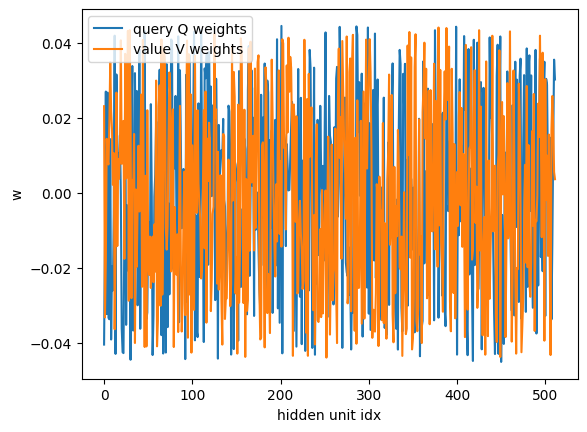

In [21]:
# what do the attention weights look like
a1 = transformer.encoder_layers[layerhead_idx].self_attn
plt.plot(a1.W_q.weight.detach().numpy()[0,:],label='query Q weights')

a1 = transformer.encoder_layers[layerhead_idx].self_attn
plt.plot(a1.W_v.weight.detach().numpy()[0,:], label = 'value V weights')
plt.xlabel('hidden unit idx')
plt.ylabel('w')
plt.legend()
plt.show()
